In [1]:
# import packages
import random
import pandas as pd
import matplotlib.pyplot as plt

## Probability of Real Roots
#### What is the probability that this quadratic equation has real roots:
#### x<sup>2</sup> + 2bx + c = 0

I decided to take a bit of an unconventional approach to this problem and perform a Monte Carlo simulation. Below I've laid out my step by step process
 - Find the discriminant
 - Create a function to test 100,000 random inputs on the discriminant between -1 and 1.
 - The function returned the count of samples with real roots and without, which when used to calculate the probability was materially equivalent to the exact probability.

Getting the discriminant 
 - A = 1
 - B = 2b
 - C = c

B<sup>2</sup> - 4AC &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;-->&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; 4b<sup>2</sup> - 4c   


In [2]:
# Define a function for the discriminant
def discriminant(b,c):
    return 4*b**2 - 4*c

The function below takes the discriminant function and simulates 100,000 random inputs for b and c, and then calculates the probability of the quadratic equation having real roots based on the cumulative results of the samples. I made the assumption that our sample space is from -1 to 1 because it was not defined in the problem. Were the sample space different these variables could be changed and the function would work the same.

In [7]:
# Define objects used in the loop:
sample_count = 0
real_roots_count = 0
no_real_roots_count = 0
history =[]

# Loop through samples until a count of 100,000 is reached
while sample_count < 100000:
    sample = discriminant(random.uniform(-1.0,1.0),random.uniform(-1.0,1.0))
    if sample >= 0:
        real_roots_count += 1
    else:
        no_real_roots_count += 1
    sample_count +=1
    history.append(real_roots_count / sample_count) # creating a df to view historical prob
print(f'''Total samples: {sample_count}
Samples with real roots: {real_roots_count}
Samples without real roots: {no_real_roots_count}
Current calculated probability = {real_roots_count/sample_count:.4f}''')

Total samples: 100000
Samples with real roots: 66744
Samples without real roots: 33256
Current calculated probability = 0.6674


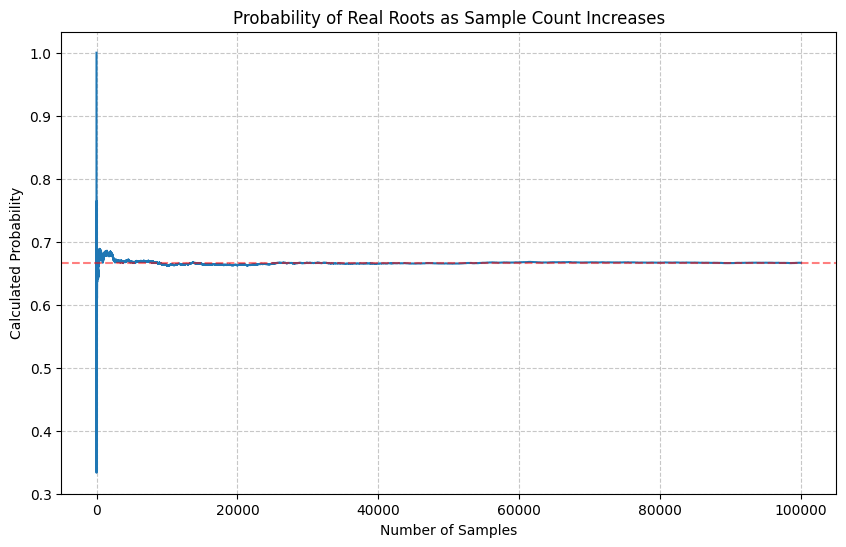

In [38]:
# Plot the results to see the how probability consolidated over time during the sampling process
plt.figure(figsize=(10, 6))
plt.plot(history)

plt.title('Probability of Real Roots as Sample Count Increases')
plt.xlabel('Number of Samples')
plt.ylabel('Calculated Probability')
plt.grid(True, linestyle='--', alpha=0.7)
# I plotted 2/3 as a horizontal line to show the exact correct answer as a check
plt.axhline(y=2/3, color='r', linestyle='--',alpha=0.5)

plt.show()

